In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

df = pd.read_csv("data/premier_league_matches_1993_2025.csv")

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

df.head()

Dataset loaded successfully!
Shape: 12,406 rows × 8 columns


,Season_End_Year,Wk,Date,Home,HomeGoals,AwayGoals,Away,FTR
0,1993,1,1992-08-15,Coventry City,2,1,Middlesbrough,H
1,1993,1,1992-08-15,Leeds United,2,1,Wimbledon,H
2,1993,1,1992-08-15,Sheffield Utd,2,1,Manchester Utd,H
3,1993,1,1992-08-15,Crystal Palace,3,3,Blackburn,D
4,1993,1,1992-08-15,Arsenal,2,4,Norwich City,A


In [4]:
df.dtypes

Season_End_Year     int64
Wk                  int64
Date               object
Home               object
HomeGoals           int64
AwayGoals           int64
Away               object
FTR                object
dtype: object

In [5]:
df.isnull().sum()

Season_End_Year    0
Wk                 0
Date               0
Home               0
HomeGoals          0
AwayGoals          0
Away               0
FTR                0
dtype: int64

In [6]:
duplicate_rows = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_rows}")

Duplicate rows: 0


In [7]:
quality_summary = pd.DataFrame({
    "dtype" : df.dtypes.astype(str),
    "null_count": df.isnull().sum(),
    "null_pct": (df.isnull().mean() * 100).round(2),
    "n_unique": df.nunique(),
}).sort_index()

quality_summary

,dtype,null_count,null_pct,n_unique
Away,object,0,0.000,50
AwayGoals,int64,0,0.000,10
Date,object,0,0.000,3395
FTR,object,0,0.000,3
Home,object,0,0.000,50
HomeGoals,int64,0,0.000,10
Season_End_Year,int64,0,0.000,32
Wk,int64,0,0.000,42


In [8]:
target_distribution = (
    df["FTR"]
    .value_counts()
    .rename_axis("FTR")
    .reset_index(name="matches")
)

target_distribution["pct"] = (target_distribution["matches"] / len(df) * 100).round(2)
target_distribution

,FTR,matches,pct
0,H,5674,45.740
1,A,3542,28.550
2,D,3190,25.710


In [9]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Date"] = pd.to_datetime(df["Date"])


df["result"] = df["FTR"].map({
    "H": "Home Win",
    "D": "Draw",
    "A": "Away Win"
})

# Create Season column
df["Season"] = df["Season_End_Year"]

# Create total goals scored in each match
df["TotalGoals"] = df["HomeGoals"] + df["AwayGoals"]

# Check the updated dataset
print("Loaded dataset")
print(f"Shape: {df.shape}")

df.head()

Loaded dataset
Shape: (12406, 11)


,Season_End_Year,Wk,Date,Home,HomeGoals,AwayGoals,Away,FTR,result,Season,TotalGoals
0,1993,1,1992-08-15,Coventry City,2,1,Middlesbrough,H,Home Win,1993,3
1,1993,1,1992-08-15,Leeds United,2,1,Wimbledon,H,Home Win,1993,3
2,1993,1,1992-08-15,Sheffield Utd,2,1,Manchester Utd,H,Home Win,1993,3
3,1993,1,1992-08-15,Crystal Palace,3,3,Blackburn,D,Draw,1993,6
4,1993,1,1992-08-15,Arsenal,2,4,Norwich City,A,Away Win,1993,6


Match outcome counts:
result
Home Win    5674
Away Win    3542
Draw        3190
Name: count, dtype: int64

Match outcome percentages:
result
Home Win   45.740
Away Win   28.550
Draw       25.710
Name: proportion, dtype: float64


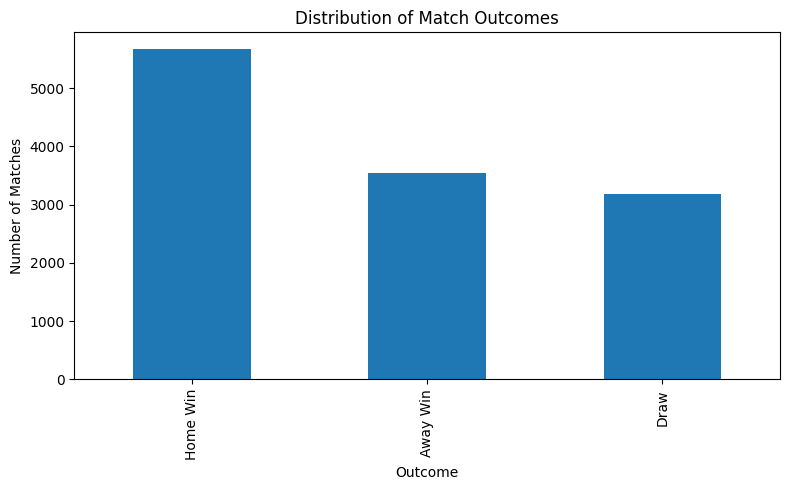

In [10]:
result_counts = df["result"].value_counts()
result_pct = df["result"].value_counts(normalize=True).mul(100).round(2)

print("Match outcome counts:")
print(result_counts)
print()
print("Match outcome percentages:")
print(result_pct)

# Visualize the class distribution.
ax = df["result"].value_counts().plot(kind="bar",figsize=(8, 5))
ax.set_title("Distribution of Match Outcomes")
ax.set_xlabel("Outcome")
ax.set_ylabel("Number of Matches")
plt.tight_layout()
plt.show()


In [11]:
numeric_summary = df.describe().T
numeric_summary

,count,mean,min,25%,50%,75%,max,std
Season_End_Year,"12,406.000","2,008.243","1,993.000","2,000.000","2,008.000","2,016.000","2,025.000",9.416
Wk,"12,406.000",19.723,1.000,10.000,20.000,29.000,42.000,11.119
Date,12406,2008-03-31 01:44:41.863614464,1992-08-15 00:00:00,2000-01-03 00:00:00,2008-02-10 00:00:00,2016-04-09 00:00:00,2025-05-25 00:00:00,NaN
HomeGoals,"12,406.000",1.524,0.000,1.000,1.000,2.000,9.000,1.306
AwayGoals,"12,406.000",1.151,0.000,0.000,1.000,2.000,9.000,1.137
Season,"12,406.000","2,008.243","1,993.000","2,000.000","2,008.000","2,016.000","2,025.000",9.416
TotalGoals,"12,406.000",2.675,0.000,1.000,2.000,4.000,11.000,1.684


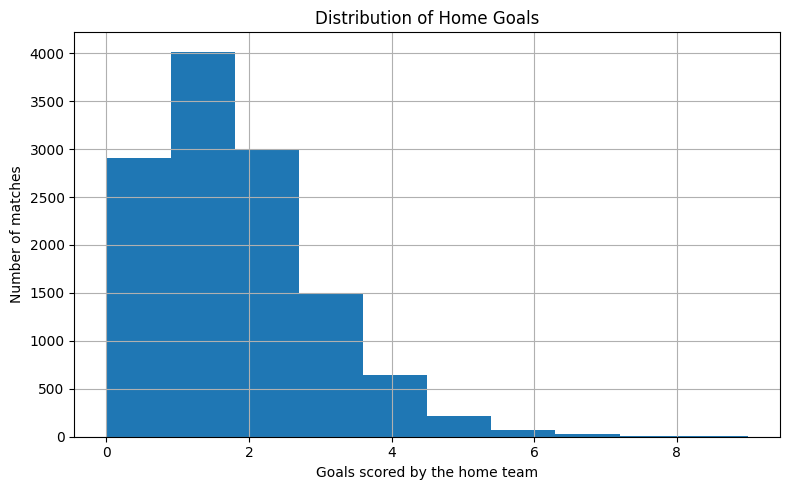

In [12]:
df["HomeGoals"].hist(bins=10, figsize=(8, 5))
plt.title("Distribution of Home Goals")
plt.xlabel("Goals scored by the home team")
plt.ylabel("Number of matches")
plt.tight_layout()
plt.show()

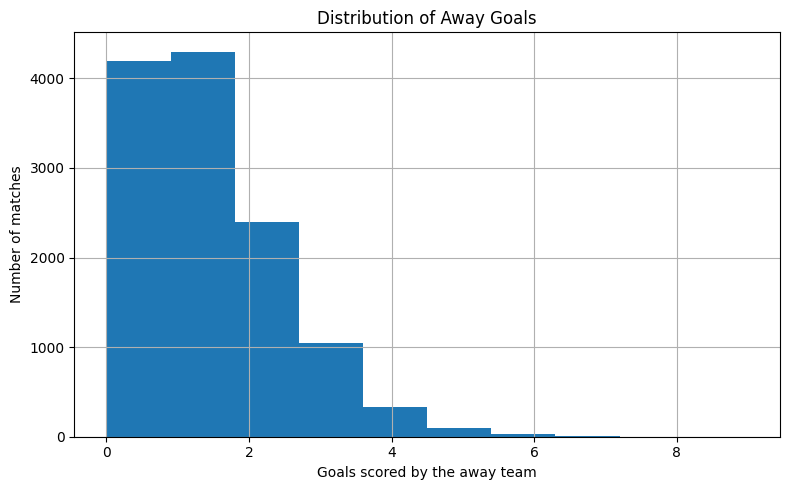

In [13]:
df["AwayGoals"].hist(bins=10, figsize=(8, 5))
plt.title("Distribution of Away Goals")
plt.xlabel("Goals scored by the away team")
plt.ylabel("Number of matches")
plt.tight_layout()
plt.show()

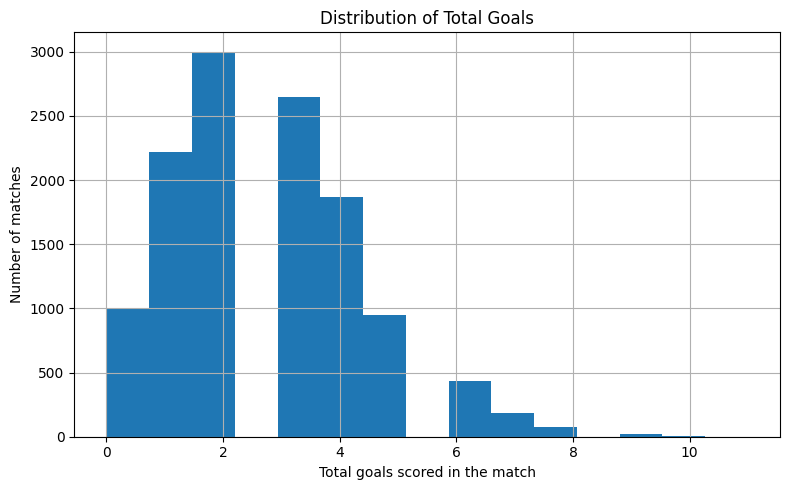

In [14]:
df["TotalGoals"].hist(bins=15, figsize=(8, 5))
plt.title("Distribution of Total Goals")
plt.xlabel("Total goals scored in the match")
plt.ylabel("Number of matches")
plt.tight_layout()
plt.show()

In [15]:
print(f"Average home goals: {df['HomeGoals'].mean():.3f}")
print(f"Average away goals: {df['AwayGoals'].mean():.3f}")
print(f"Average total goals: {df['TotalGoals'].mean():.3f}")

Average home goals: 1.524
Average away goals: 1.151
Average total goals: 2.675


HomeGoals   1.524
AwayGoals   1.151
dtype: float64


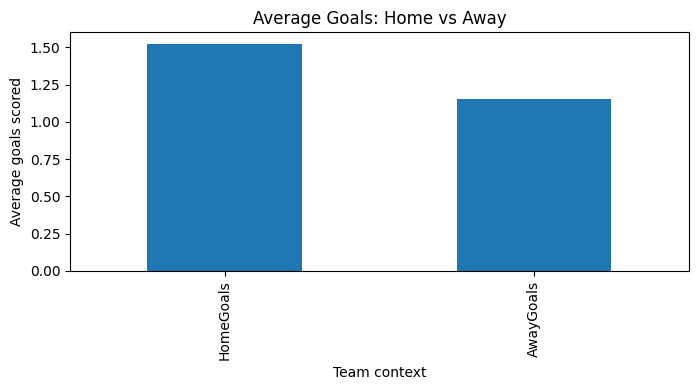

In [16]:
avg_goals = pd.Series({
    "HomeGoals": df["HomeGoals"].mean(),
    "AwayGoals": df["AwayGoals"].mean()
})

print(avg_goals.round(3))

ax = avg_goals.plot(kind="bar", figsize=(7, 4))
ax.set_title("Average Goals: Home vs Away")
ax.set_xlabel("Team context")
ax.set_ylabel("Average goals scored")
plt.tight_layout()
plt.show()

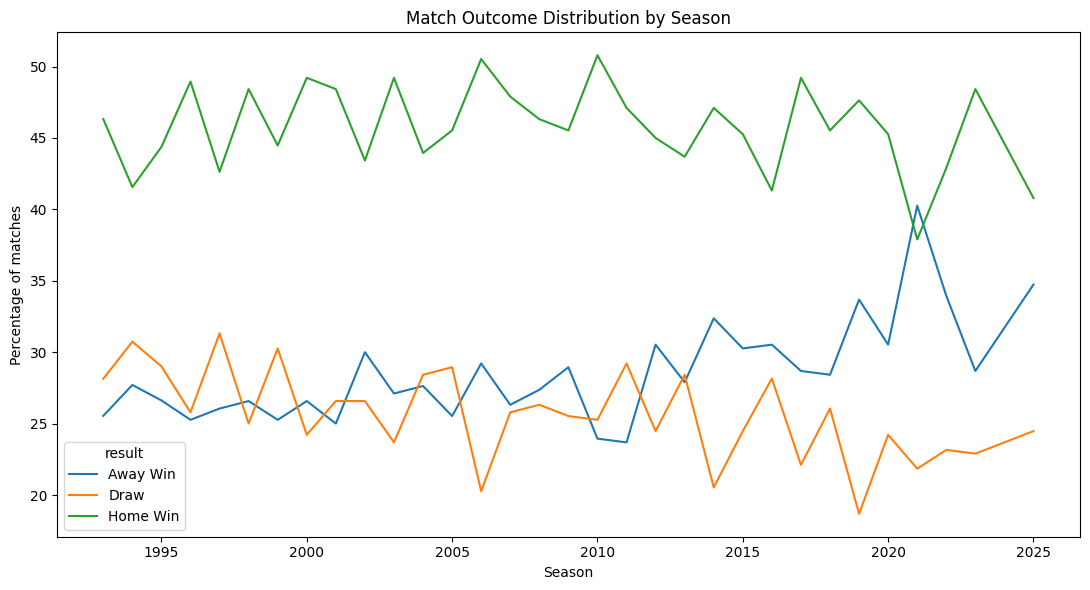

result,Away Win,Draw,Home Win
Season,,,
2020,30.526,24.211,45.263
2021,40.263,21.842,37.895
2022,33.947,23.158,42.895
2023,28.684,22.895,48.421
2025,34.737,24.474,40.789


In [17]:
season_result_share = (
    df.groupby("Season")["result"]
      .value_counts(normalize=True)
      .rename("share")
      .mul(100)
      .reset_index()
)

pivot_share = season_result_share.pivot(
    index="Season", columns="result", values="share"
).sort_index()

pivot_share.plot(figsize=(11, 6))
plt.title("Match Outcome Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Percentage of matches")
plt.tight_layout()
plt.show()

pivot_share.tail()

In [18]:
df["home_scored_last5"] = (
    df.groupby("Home")["HomeGoals"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

df["away_scored_last5"] = (
    df.groupby("Away")["AwayGoals"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

df["home_conceded_last5"] = (
    df.groupby("Home")["AwayGoals"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

df["away_conceded_last5"] = (
    df.groupby("Away")["HomeGoals"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

df["home_goal_balance_last5"] = df["home_scored_last5"] - df["home_conceded_last5"]
df["away_goal_balance_last5"] = df["away_scored_last5"] - df["away_conceded_last5"]

feature_columns = [
    "Home",
    "Away",
    "home_scored_last5",
    "away_scored_last5",
    "home_conceded_last5",
    "away_conceded_last5",
    "home_goal_balance_last5",
    "away_goal_balance_last5"
]

target_column = "FTR"

display(df[["Date"] + feature_columns + [target_column]].head(10))   

,Date,Home,Away,home_scored_last5,away_scored_last5,home_conceded_last5,away_conceded_last5,home_goal_balance_last5,away_goal_balance_last5,FTR
0,1992-08-15,Coventry City,Middlesbrough,NaN,NaN,NaN,NaN,NaN,NaN,H
1,1992-08-15,Leeds United,Wimbledon,NaN,NaN,NaN,NaN,NaN,NaN,H
2,1992-08-15,Sheffield Utd,Manchester Utd,NaN,NaN,NaN,NaN,NaN,NaN,H
3,1992-08-15,Crystal Palace,Blackburn,NaN,NaN,NaN,NaN,NaN,NaN,D
4,1992-08-15,Arsenal,Norwich City,NaN,NaN,NaN,NaN,NaN,NaN,A
5,1992-08-15,Ipswich Town,Aston Villa,NaN,NaN,NaN,NaN,NaN,NaN,D
6,1992-08-15,Everton,Sheffield Weds,NaN,NaN,NaN,NaN,NaN,NaN,D
7,1992-08-15,Southampton,Tottenham,NaN,NaN,NaN,NaN,NaN,NaN,D
8,1992-08-15,Chelsea,Oldham Athletic,NaN,NaN,NaN,NaN,NaN,NaN,D
9,1992-08-16,Nott'ham Forest,Liverpool,NaN,NaN,NaN,NaN,NaN,NaN,H


In [19]:
split_index = int(len(df) * 0.80)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

X_train = train_df[feature_columns]
X_test = test_df[feature_columns]
y_train = train_df[target_column]
y_test = test_df[target_column]

print(f"Training rows:  {len(train_df)}")
print(f"Test rows:      {len(test_df)}")
print(f"Train period:   {train_df['Date'].min().date()} -> {train_df['Date'].max().date()}")
print(f"Test period:    {test_df['Date'].min().date()} -> {test_df['Date'].max().date()}")


Training rows:  9924
Test rows:      2482
Train period:   1992-08-15 -> 2017-12-17
Test period:    2017-12-17 -> 2025-05-25


In [20]:
categorical_features = ["Home", "Away"]
numeric_features = [
    "home_scored_last5",
    "away_scored_last5",
    "home_conceded_last5",
    "away_conceded_last5",
    "home_goal_balance_last5",
    "away_goal_balance_last5",
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=2000)),
    ]
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [21]:
# Model predictions.
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# Simple baseline: always predict the most frequent class.
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

model_accuracy = accuracy_score(y_test, y_pred)
baseline_accuracy = accuracy_score(y_test, baseline_pred)
model_logloss = log_loss(y_test, y_pred_proba, labels=model.classes_)

results_summary = pd.DataFrame(
    {
        "Metric": ["Model accuracy", "Baseline accuracy", "Model log loss"],
        "Value": [model_accuracy, baseline_accuracy, model_logloss],
    }
)

display(results_summary)

print("Classification Report:")
print(classification_report(y_test, y_pred))

,Metric,Value
0,Model accuracy,0.508
1,Baseline accuracy,0.440
2,Model log loss,1.025


Classification Report:
              precision    recall  f1-score   support

           A       0.51      0.44      0.47       820
           D       0.32      0.08      0.12       571
           H       0.52      0.79      0.63      1091

    accuracy                           0.51      2482
   macro avg       0.45      0.43      0.41      2482
weighted avg       0.47      0.51      0.46      2482



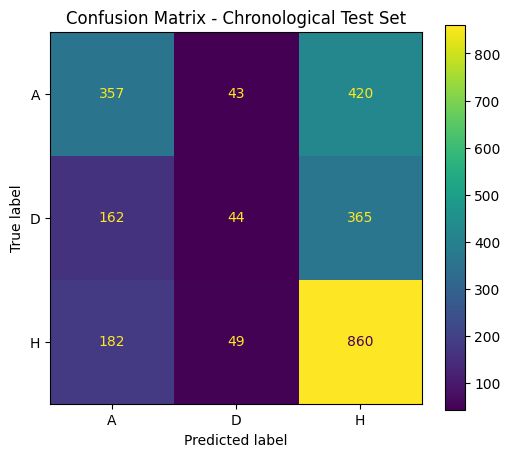

In [22]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax)
plt.title("Confusion Matrix - Chronological Test Set")
plt.show()

In [62]:
metrics_table = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Balanced Accuracy",
            "Macro F1",
            "Weighted F1"
        ],
        "Logistic Regression": [
            accuracy_score(y_test, y_pred),
            balanced_accuracy_score(y_test, y_pred),
            f1_score(y_test, y_pred, average="macro"),
            f1_score(y_test, y_pred, average="weighted")
        ],
        "Naive Baseline": [
            accuracy_score(y_test, baseline_pred),
            balanced_accuracy_score(y_test, baseline_pred),
            f1_score(y_test, baseline_pred, average="macro", zero_division=0),
            f1_score(y_test, baseline_pred, average="weighted", zero_division=0)
        ]
    }
)

metrics_table["Improvement vs Baseline"] = (
    metrics_table["Logistic Regression"]
    - metrics_table["Naive Baseline"]
)

metrics_table.style.format(
    {
        "Logistic Regression": "{:.3f}",
        "Naive Baseline": "{:.3f}",
        "Improvement vs Baseline": "{:+.3f}"
    }
)

,Metric,Logistic Regression,Naive Baseline,Improvement vs Baseline
0,Accuracy,0.508,0.440,+0.068
1,Balanced Accuracy,0.434,0.333,+0.100
2,Macro F1,0.408,0.204,+0.204
3,Weighted F1,0.460,0.268,+0.192


In [23]:
class_order = ["A", "D", "H"]
class_names = ["Away Win", "Draw", "Home Win"]

report = classification_report(
    y_test,
    y_pred,
    labels=class_order,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report).T
report_df

,precision,recall,f1-score,support
Away Win,0.509,0.435,0.469,820.000
Draw,0.324,0.077,0.124,571.000
Home Win,0.523,0.788,0.629,"1,091.000"
accuracy,0.508,0.508,0.508,0.508
macro avg,0.452,0.434,0.408,"2,482.000"
weighted avg,0.472,0.508,0.460,"2,482.000"


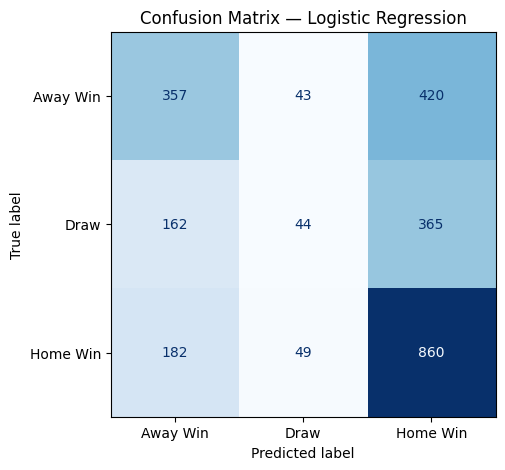

In [24]:
cm = confusion_matrix(y_test, y_pred, labels=class_order)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — Logistic Regression")
plt.show()